# Topic Perturbation Analysis

This tutorial evaluates the robustness and biological relevance of learned topics by systematically perturbing topics and assessing the impact on cell

## Part 1: Identifying Cell Type-Specific Topics 

In [ ]:
"""
Differential Topic Expression Analysis
This script identifies topics that are differentially expressed between cell types,
helping to interpret which topics capture specific cell type signatures.
"""

import numpy as np
import pandas as pd
import os
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# ============================================================================
# Helper Functions for Statistical Testing
# ============================================================================

def permutation_two_sided(inside_group, outside_group, n_permutations=1000):
    """
    Two-sided permutation test to check if the absolute mean difference is significant.
    
    Parameters:
    -----------
    inside_group : np.ndarray
        Scores for cells in the target group
    outside_group : np.ndarray
        Scores for cells not in the target group
    n_permutations : int
        Number of permutations for the test
    
    Returns:
    --------
    p_value : float
        Two-sided p-value from permutation test
    """
    # Calculate observed absolute difference
    observed_diff = np.mean(inside_group) - np.mean(outside_group)
    observed_abs_diff = abs(observed_diff)
    
    # Combine groups for permutation
    combined = np.concatenate([inside_group, outside_group])
    n_inside = len(inside_group)
    
    count_extreme = 0
    
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        perm_inside = combined[:n_inside]
        perm_outside = combined[n_inside:]
        perm_diff = np.mean(perm_inside) - np.mean(perm_outside)
        
        # Count permutations with equal or larger absolute difference
        if abs(perm_diff) >= observed_abs_diff:
            count_extreme += 1
    
    # Add 1 to both numerator and denominator for unbiased p-value estimation
    p_value = (count_extreme + 1) / (n_permutations + 1)
    return p_value


def permutation_one_sided(inside_group, outside_group, n_permutations=1000):
    """
    One-sided permutation test to check if inside_group has significantly higher scores.
    
    Parameters:
    -----------
    inside_group : np.ndarray
        Scores for cells in the target group
    outside_group : np.ndarray
        Scores for cells not in the target group
    n_permutations : int
        Number of permutations for the test
    
    Returns:
    --------
    p_value : float
        One-sided p-value (testing if inside_group > outside_group)
    """
    # Calculate observed difference
    observed_diff = np.mean(inside_group) - np.mean(outside_group)
    
    # If observed difference is negative, return non-significant
    if observed_diff <= 0:
        return 1.0
    
    # Combine groups for permutation
    combined = np.concatenate([inside_group, outside_group])
    n_inside = len(inside_group)
    
    count_extreme = 0
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        perm_inside = combined[:n_inside]
        perm_outside = combined[n_inside:]
        perm_diff = np.mean(perm_inside) - np.mean(perm_outside)
        
        if perm_diff >= observed_diff:
            count_extreme += 1
    
    p_value = (count_extreme + 1) / (n_permutations + 1)
    return p_value


# ============================================================================
# Main Analysis Functions
# ============================================================================

def calculate_topic_differences(topic_matrix, cell_type_labels, method='ttest', n_permutations=1000):
    """
    Calculate differential expression of topics across cell types (directional).
    
    For each topic and each cell type, this function tests whether cells of that type
    have significantly higher topic scores compared to all other cells.
    
    Parameters:
    -----------
    topic_matrix : np.ndarray [n_cells, n_topics]
        Topic distribution matrix (each cell's topic weights)
    cell_type_labels : np.ndarray [n_cells]
        Ground truth cell type annotations
    method : str
        Statistical test method: 'ttest' (Mann-Whitney U) or 'permutation'
    n_permutations : int
        Number of permutations for permutation test
    
    Returns:
    --------
    pd.DataFrame
        Results containing topic-cell type associations with statistics
    """
    # Ensure numeric type for calculations
    topic_matrix = topic_matrix.astype(float)
    unique_cell_types = np.unique(cell_type_labels)
    n_topics = topic_matrix.shape[1]
    
    results = []
    
    for topic_idx in tqdm(range(n_topics), desc="Analyzing topics"):
        topic_scores = topic_matrix[:, topic_idx]
        
        for cell_type in unique_cell_types:
            # Create masks for cells in/out of current cell type
            in_mask = (cell_type_labels == cell_type)
            out_mask = ~in_mask
            
            # Skip if either group has too few cells (minimum 5)
            if np.sum(in_mask) < 5 or np.sum(out_mask) < 5:
                continue
                
            in_scores = topic_scores[in_mask]
            out_scores = topic_scores[out_mask]
            
            # Calculate directional mean difference (positive = enriched in this cell type)
            mean_diff = np.mean(in_scores) - np.mean(out_scores)
            
            if method == 'ttest':
                # Use Mann-Whitney U test (non-parametric alternative to t-test)
                _, p_value = mannwhitneyu(in_scores, out_scores, alternative='two-sided')
                    
            elif method == 'permutation':
                # Use two-sided permutation test
                p_value = permutation_two_sided(in_scores, out_scores, n_permutations)
            
            # Store results
            results.append({
                'Topic': f'Topic_{topic_idx:02d}',
                'Cell_Type': cell_type,
                'Mean_Difference': mean_diff,
                'P_Value': p_value,
                'N_In_Group': len(in_scores),
                'N_Out_Group': len(out_scores)
            })
    
    return pd.DataFrame(results)


def apply_multiple_testing_correction(results_df, method='fdr'):
    """
    Apply multiple testing correction to p-values.
    
    Parameters:
    -----------
    results_df : pd.DataFrame
        DataFrame containing p-values from differential testing
    method : str
        Correction method: 'bonferroni' or 'fdr' (False Discovery Rate)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with added adjusted p-values and significance flags
    """
    p_values = results_df['P_Value'].values
    
    if method == 'bonferroni':
        # Bonferroni correction (more conservative)
        n_tests = len(p_values)
        adjusted_p = p_values * n_tests
        adjusted_p = np.clip(adjusted_p, 0, 1)  # Cap at 1
        
    elif method == 'fdr':
        # FDR correction using Benjamini-Hochberg
        rejected, adjusted_p, _, _ = multipletests(p_values, method='fdr_bh')
    
    results_df['Adjusted_P_Value'] = adjusted_p
    results_df['Significant'] = results_df['Adjusted_P_Value'] < 0.05
    
    return results_df


def filter_significant_results(results_df, mean_diff_threshold=1):
    """
    Filter results based on significance and mean difference threshold.
    
    Parameters:
    -----------
    results_df : pd.DataFrame
        DataFrame with adjusted p-values and mean differences
    mean_diff_threshold : float
        Minimum absolute mean difference to consider significant
    
    Returns:
    --------
    pd.DataFrame
        Filtered results with significant associations
    """
    # Filter: significant AND mean difference exceeds threshold
    significant_mask = (results_df['Significant']) & (abs(results_df['Mean_Difference']) > mean_diff_threshold)
    
    return results_df[significant_mask].copy()


def run_complete_analysis(topic_matrix, cell_type_labels, mean_diff_threshold=1):
    """
    Complete analysis workflow for differential topic expression.
    
    Parameters:
    -----------
    topic_matrix : np.ndarray [n_cells, n_topics]
        Topic distribution matrix
    cell_type_labels : np.ndarray [n_cells]
        Cell type annotations
    mean_diff_threshold : float
        Threshold for mean difference significance
    
    Returns:
    --------
    dict
        Dictionary containing all analysis results
    """
    # Step 1: Calculate directional differences
    print("Step 1: Calculating topic differences...")
    results_df = calculate_topic_differences(
        topic_matrix, 
        cell_type_labels, 
        method='ttest'
    )
    
    # Step 2: Apply multiple testing correction
    print("Step 2: Applying multiple testing correction...")
    results_df = apply_multiple_testing_correction(results_df, method='fdr')
    
    # Step 3: Filter significant results
    print("Step 3: Filtering significant results...")
    significant_results = filter_significant_results(results_df, mean_diff_threshold)
    print(f"Found {len(significant_results)} significant topic-cell type associations")
    
    return {
        'all_results': results_df,
        'significant_results': significant_results,
    }


# ============================================================================
# Main Execution
# ============================================================================

if __name__ == "__main__":
    import scanpy as sc
    
    # ============================================================================
    # Configuration - Set paths
    # ============================================================================
    
    # Get current directory (works in both script and Jupyter notebook)
    try:
        current_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        current_dir = os.getcwd()
    
    # Dataset name (modify as needed)
    dataset_name = 'Melanoma'
    
    # Define paths relative to project root
    # Project structure:
    # scE2TM_github/
    # ├── tutorial/                    # This script is here
    # │   └── differential_topic_analysis.py
    # ├── output/
    # │   └── Melanoma/
    # │       └── {dataset_name}_topic_distribution.csv
    # └── data/
    #     └── {dataset_name}_cell_anno.csv
    
    project_root = os.path.join(current_dir, '..')
    embedding_path = os.path.join(project_root, 'output', dataset_name, f'{dataset_name}_topic_distribution.csv')
    label_path = os.path.join(project_root, 'data', f'{dataset_name}_cell_anno.csv')
    
    print(f"Loading embeddings from: {embedding_path}")
    print(f"Loading labels from: {label_path}")
    
    # ============================================================================
    # Load Data
    # ============================================================================
    
    # Load topic embeddings
    # The embedding file contains cell embeddings (rows = cells, columns = topics)
    embedding_df = pd.read_csv(embedding_path)
    
    # Extract embedding values (skip first column if it contains cell indices)
    # First column is typically cell identifiers, so we take all columns from index 1
    embedding_values = embedding_df.values[:, 1:]
    print(f"Loaded topic matrix shape: {embedding_values.shape}")
    
    # Load cell type annotations
    label_df = pd.read_csv(label_path, sep=',', index_col=0)
    # Use the first column as cell type labels
    cell_type_labels = list(label_df.iloc[:, 0])
    print(f"Loaded {len(cell_type_labels)} cell type labels")
    print(f"Unique cell types: {np.unique(cell_type_labels)}")
    
    # ============================================================================
    # Run Analysis
    # ============================================================================
    
    print("\n" + "="*60)
    print("Starting Differential Topic Expression Analysis")
    print("="*60 + "\n")
    
    # Run complete analysis workflow
    analysis_results = run_complete_analysis(
        embedding_values, 
        np.array(cell_type_labels),
        mean_diff_threshold=1  # Adjust threshold as needed
    )
    
    print("\n" + "="*60)
    print("Analysis Complete!")
    print("="*60)

Total topics analyzed: 100

Significant topics (enriched in malignant cells): 33

Top significant topics:
        Topic  Mean_Difference  Adjusted_P_Value
6    Topic_00         2.009215               0.0
13   Topic_01         1.802827               0.0
34   Topic_04         1.957687               0.0
97   Topic_13         1.880839               0.0
104  Topic_14         1.950759               0.0
132  Topic_18         1.744521               0.0
146  Topic_20         2.054788               0.0
167  Topic_23         1.954696               0.0
195  Topic_27         1.997606               0.0
209  Topic_29         2.002700               0.0


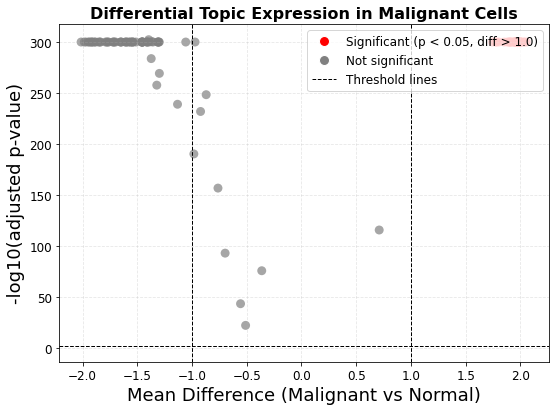


Summary Statistics
Total topics analyzed: 100
Significant topics (enriched in malignant cells): 33
Significance threshold: p < 0.05
Mean difference threshold: > 1.0

Top 5 topics by mean difference:
  Topic_20: diff = 2.0548, p = 0.00e+00
  Topic_91: diff = 2.0373, p = 0.00e+00
  Topic_62: diff = 2.0302, p = 0.00e+00
  Topic_00: diff = 2.0092, p = 0.00e+00
  Topic_90: diff = 2.0055, p = 0.00e+00


In [10]:
"""
Volcano Plot for Differential Topic Analysis
This visualization shows topics that are significantly enriched in malignant cells
compared to normal cells, based on mean difference and adjusted p-values.
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================================
# Extract Malignant Cell Results
# ============================================================================

# Get all analysis results and filter for malignant cells
# This compares malignant cells vs all other cells (normal cells)
analysis_results_df = analysis_results["all_results"]
malignant_results = analysis_results_df[analysis_results_df.Cell_Type == 'malignant'].copy()

print(f"Total topics analyzed: {len(malignant_results)}")

# ============================================================================
# Prepare Data for Visualization
# ============================================================================

# Calculate -log10(adjusted p-value) for better visualization
# Small p-values become large positive values on the y-axis
# Replace zeros with a very small number to avoid -inf
malignant_results['-log10(FDR)'] = -np.log10(malignant_results['Adjusted_P_Value'].replace(0, 1e-300))

# Define significance thresholds
# Topics with adjusted p-value < 0.05 are considered statistically significant
# Topics with mean difference > 1 are considered biologically meaningful
pvalue_threshold = 0.05
logfc_threshold = 1.0  # Mean difference threshold (enrichment in malignant cells)

# ============================================================================
# Color Coding Based on Significance
# ============================================================================

# Assign colors based on significance and direction
# Red: Significantly enriched in malignant cells (p < 0.05 AND mean_diff > 1)
# Grey: Not significant or not meeting threshold
colors = malignant_results.apply(
    lambda row: 'red' if (row['Adjusted_P_Value'] < pvalue_threshold and 
                          row['Mean_Difference'] > logfc_threshold)
    else 'grey',
    axis=1
)

# ============================================================================
# Identify and Count Significant Topics
# ============================================================================

# Filter for significant topics (enriched in malignant cells)
significant_topics = malignant_results[
    (malignant_results['Adjusted_P_Value'] < pvalue_threshold) & 
    (malignant_results['Mean_Difference'] > logfc_threshold)
]

print(f"\nSignificant topics (enriched in malignant cells): {len(significant_topics)}")
print("\nTop significant topics:")
print(significant_topics[['Topic', 'Mean_Difference', 'Adjusted_P_Value']].head(10))

# ============================================================================
# Create Volcano Plot
# ============================================================================

plt.figure(figsize=(8, 6))

# Scatter plot of all topics
plt.scatter(
    malignant_results['Mean_Difference'], 
    malignant_results['-log10(FDR)'], 
    c=colors, 
    alpha=0.7, 
    s=80, 
    edgecolor='none'
)

# Add reference lines
# Horizontal line: significance threshold (p = 0.05)
plt.axhline(
    y=-np.log10(pvalue_threshold), 
    color='black', 
    linestyle='--', 
    linewidth=1, 
    label=f'p = {pvalue_threshold}'
)

# Vertical lines: mean difference thresholds
plt.axvline(
    x=logfc_threshold, 
    color='black', 
    linestyle='--', 
    linewidth=1, 
    label=f'Mean diff = {logfc_threshold}'
)
plt.axvline(
    x=-logfc_threshold, 
    color='black', 
    linestyle='--', 
    linewidth=1
)

# Optional: Annotate significant topics (uncomment to add labels)
# for idx, row in significant_topics.iterrows():
#     plt.text(
#         row['Mean_Difference'], 
#         row['-log10(FDR)'] + 0.2, 
#         row['Topic'],
#         fontsize=10, 
#         ha='center', 
#         fontweight='bold'
#     )

# Set axis labels and styling
plt.xlabel('Mean Difference (Malignant vs Normal)', fontsize=18)
plt.ylabel('-log10(adjusted p-value)', fontsize=18)
plt.title('Differential Topic Expression in Malignant Cells', fontsize=16, fontweight='bold')

# Add grid for better readability
plt.grid(alpha=0.3, linestyle='--')

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
           markersize=10, label=f'Significant (p < {pvalue_threshold}, diff > {logfc_threshold})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', 
           markersize=10, label='Not significant'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=1, label='Threshold lines')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the plot
plt.show()

# ============================================================================
# Summary Statistics
# ============================================================================

print("\n" + "="*60)
print("Summary Statistics")
print("="*60)
print(f"Total topics analyzed: {len(malignant_results)}")
print(f"Significant topics (enriched in malignant cells): {len(significant_topics)}")
print(f"Significance threshold: p < {pvalue_threshold}")
print(f"Mean difference threshold: > {logfc_threshold}")

if len(significant_topics) > 0:
    print(f"\nTop 5 topics by mean difference:")
    top_topics = significant_topics.nlargest(5, 'Mean_Difference')
    for idx, row in top_topics.iterrows():
        print(f"  {row['Topic']}: diff = {row['Mean_Difference']:.4f}, "
              f"p = {row['Adjusted_P_Value']:.2e}")

## Part 2: Visualization of reconstructed space after perturbing malignant-specific topics

In [11]:
"""
Topic Perturbation Analysis - Data Loading and Preparation
This script loads original and perturbed reconstructed gene expression matrices 
from scE2TM for perturbation analysis.
"""

import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import os

# ============================================================================
# Configuration
# ============================================================================

# Get current directory (works in both script and Jupyter notebook)
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

# Dataset configuration
dataset_name = 'Melanoma'

# Define paths relative to project root
project_root = os.path.join(current_dir, '..')
data_dir = os.path.join(project_root, 'data')
output_dir = os.path.join(project_root, 'output', dataset_name)

# Input file paths
expression_file = os.path.join(data_dir, f'{dataset_name}_HIGHPRE.csv')
label_file = os.path.join(data_dir, f'{dataset_name}_cell_anno.csv')

# Reconstructed gene expression matrices from scE2TM
# recon_0: Original reconstruction from full topic distribution
# per_recon_0: Reconstruction after perturbing specific topics
original_reconstruction_file = os.path.join(output_dir, f'{dataset_name}_recon_0.npy')
perturbed_reconstruction_file = os.path.join(output_dir, f'{dataset_name}_per_recon_0.npy')

print(f"Loading data from:")
print(f"  Expression: {expression_file}")
print(f"  Labels: {label_file}")
print(f"  Original reconstruction: {original_reconstruction_file}")
print(f"  Perturbed reconstruction: {perturbed_reconstruction_file}")

# ============================================================================
# Load Expression Data and Cell Annotations
# ============================================================================

# Load original gene expression data (ground truth)
expression_data = pd.read_csv(expression_file, sep=',', index_col=0)
print(f"\nOriginal expression data shape: {expression_data.shape}")

# Load cell type annotations
label_df = pd.read_csv(label_file, sep=',', index_col=0)
cell_type_labels = list(label_df.iloc[:, 0])
print(f"Loaded {len(cell_type_labels)} cell type labels")

# Create AnnData object for reference
reference_adata = sc.AnnData(expression_data)
reference_adata.obs["cell_type"] = cell_type_labels

# Create binary condition labels (malignant vs normal)
condition_labels = ['malignant' if cell_type == 'malignant' else 'normal' 
                    for cell_type in cell_type_labels]
reference_adata.obs["condition"] = condition_labels

print(f"\nCondition distribution:")
print(f"  Malignant cells: {sum(np.array(condition_labels) == 'malignant')}")
print(f"  Normal cells: {sum(np.array(condition_labels) == 'normal')}")

# ============================================================================
# Load Reconstructed Gene Expression Matrices
# ============================================================================

# Load original reconstructed expression (from full topic distribution)
# This is scE2TM's reconstruction of gene expression using all topics
original_reconstructed = np.load(original_reconstruction_file)
print(f"\nOriginal reconstructed expression shape: {original_reconstructed.shape}")

# Load perturbed reconstructed expression (after removing a specific topic)
# This represents how gene expression changes when a topic is removed
perturbed_reconstructed = np.load(perturbed_reconstruction_file)
print(f"Perturbed reconstructed expression shape: {perturbed_reconstructed.shape}")

# ============================================================================
# Split Data by Condition
# ============================================================================

# Create boolean masks for condition filtering
is_normal = np.array(reference_adata.obs["condition"]) == 'normal'
is_malignant = np.array(reference_adata.obs["condition"]) == 'malignant'

# Split original reconstructions by condition
original_normal_recon = original_reconstructed[is_normal]
original_malignant_recon = original_reconstructed[is_malignant]

# Split cell type labels by condition
normal_cell_types = list(reference_adata.obs["cell_type"][is_normal])
malignant_cell_types = list(reference_adata.obs["cell_type"][is_malignant])

# Perturbed reconstructions (in silico stimulated condition)
# These are from the same malignant cells but with topic removed
perturbed_malignant_recon = perturbed_reconstructed

print(f"\nData split summary:")
print(f"  Normal cells (original recon): {len(original_normal_recon)}")
print(f"  Malignant cells (original recon): {len(original_malignant_recon)}")
print(f"  Malignant cells (perturbed recon): {len(perturbed_malignant_recon)}")

# ============================================================================
# Create AnnData Objects for Different Conditions
# ============================================================================

# AnnData for normal condition (baseline control)
adata_normal = ad.AnnData(original_normal_recon)
adata_normal.obs['cell_type'] = normal_cell_types
adata_normal.obs['condition'] = 'Normal'

# AnnData for malignant condition (original, unperturbed reconstruction)
adata_malignant_original = ad.AnnData(original_malignant_recon)
adata_malignant_original.obs['cell_type'] = malignant_cell_types
adata_malignant_original.obs['condition'] = 'Malignant_Original'

# AnnData for perturbed condition (reconstruction after topic removal)
adata_malignant_perturbed = ad.AnnData(perturbed_malignant_recon)
adata_malignant_perturbed.obs['cell_type'] = malignant_cell_types
adata_malignant_perturbed.obs['condition'] = 'Malignant_Perturbed'

# ============================================================================
# Combine Datasets for Integrated Analysis
# ============================================================================

# Combine normal and original malignant datasets
# This will be used to evaluate how well the reconstruction preserves
# the distinction between normal and malignant cells
adata_combined = ad.concat(
    [adata_normal, adata_malignant_original], 
    label="batch_index"
)
adata_combined.obs['condition'] = adata_combined.obs['condition'].astype('category')

# Create reference labels for evaluation (ground truth)
reference_labels = (['Normal'] * len(adata_normal) + 
                   ['Malignant'] * len(adata_malignant_original))

print(f"\nCombined dataset summary:")
print(f"  Total cells: {len(adata_combined)}")
print(f"  Condition distribution: {adata_combined.obs['condition'].value_counts().to_dict()}")
print(f"  Reference labels prepared for evaluation")

# ============================================================================
# Optional: Compare Original vs Perturbed Reconstructions
# ============================================================================

# Calculate reconstruction error between original and perturbed
# This quantifies the impact of topic removal on gene expression
reconstruction_diff = np.mean((original_malignant_recon - perturbed_malignant_recon) ** 2)
print(f"\nReconstruction difference after perturbation:")
print(f"  MSE between original and perturbed: {reconstruction_diff:.6f}")

Loading data from:
  Expression: /mnt/rao/home/chenhg/Methods/ECRTM-Singlecell/scE2TM_github/tutorial/../data/Melanoma_HIGHPRE.csv
  Labels: /mnt/rao/home/chenhg/Methods/ECRTM-Singlecell/scE2TM_github/tutorial/../data/Melanoma_cell_anno.csv
  Original reconstruction: /mnt/rao/home/chenhg/Methods/ECRTM-Singlecell/scE2TM_github/tutorial/../output/Melanoma/Melanoma_recon_0.npy
  Perturbed reconstruction: /mnt/rao/home/chenhg/Methods/ECRTM-Singlecell/scE2TM_github/tutorial/../output/Melanoma/Melanoma_per_recon_0.npy

Original expression data shape: (4092, 10000)
Loaded 4092 cell type labels

Condition distribution:
  Malignant cells: 1252
  Normal cells: 2840

Original reconstructed expression shape: (4092, 10000)
Perturbed reconstructed expression shape: (1252, 10000)

Data split summary:
  Normal cells (original recon): 2840
  Malignant cells (original recon): 1252
  Malignant cells (perturbed recon): 1252

Combined dataset summary:
  Total cells: 4092
  Condition distribution: {'Normal'

/mnt/rao/home/chenhg/.local/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [12]:
"""
UMAP Visualization for Perturbation Analysis
This section visualizes the reference and perturbed reconstructions using UMAP,
with density plots to show distribution shifts after topic removal.
"""

import umap
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# UMAP Configuration
# ============================================================================

# Initialize UMAP model with consistent parameters
# Using the same parameters ensures fair comparison between conditions
umap_model = umap.UMAP(
    n_neighbors=15,      # Number of neighbors for local structure preservation
    n_components=2,      # Reduce to 2 dimensions for visualization
    min_dist=0.1,        # Minimum distance between points in embedding
    metric='euclidean',  # Distance metric for UMAP
    random_state=42,     # Fixed random seed for reproducibility
    verbose=True         # Print progress information
)

print("Fitting UMAP on combined dataset...")

# ============================================================================
# Fit UMAP on Combined Reference Data
# ============================================================================

# Fit UMAP on the combined dataset (normal + original malignant)
# This establishes the reference embedding space
reference_umap = umap_model.fit_transform(adata_combined.X)

print(f"Reference UMAP shape: {reference_umap.shape}")

# ============================================================================
# Transform Perturbed Data into Reference Space
# ============================================================================

# Project the perturbed reconstruction into the same UMAP space
# This allows direct comparison of how perturbed samples are positioned
# relative to the reference embedding
in_silico_umap = umap_model.transform(adata_malignant_perturbed.X)

print(f"In silico perturbed UMAP shape: {in_silico_umap.shape}")

Fitting UMAP on combined dataset...
UMAP(random_state=42, verbose=True)


/mnt/rao/home/chenhg/anaconda3/envs/scE2TM/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Wed Mar 25 12:12:03 2026 Construct fuzzy simplicial set
Wed Mar 25 12:17:37 2026 Finding Nearest Neighbors
Wed Mar 25 12:17:43 2026 Finished Nearest Neighbor Search
Wed Mar 25 12:17:50 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Mar 25 12:18:14 2026 Finished embedding
Reference UMAP shape: (4092, 2)


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
In silico perturbed UMAP shape: (1252, 2)


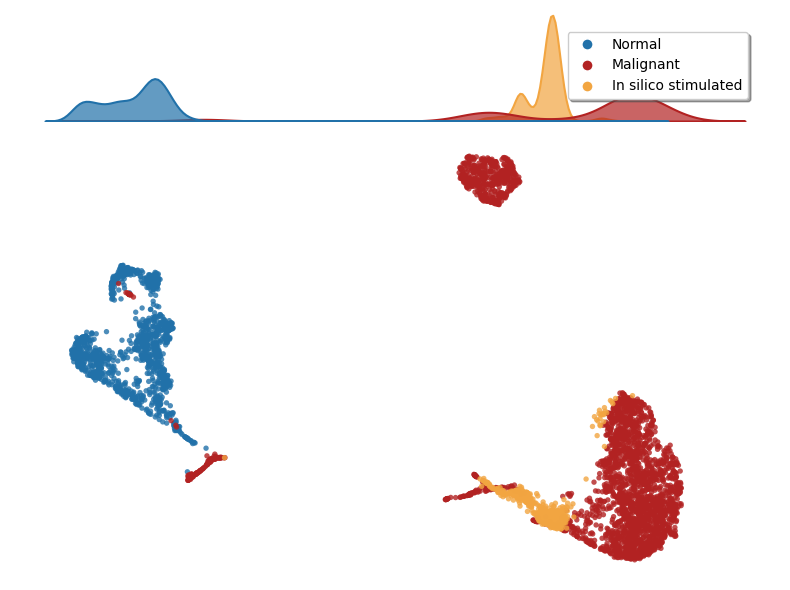


UMAP Visualization Summary
Total cells visualized: 5344
  - Normal cells: 2840
  - Malignant cells (original): 1252
  - In silico stimulated (perturbed): 1252

Distribution shift after topic removal:
  Compare the KDE plot to see how the perturbed cells
  are positioned relative to the original populations.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import anndata as ad

# ============================================================================
# Visualization Settings
# ============================================================================

# Use default matplotlib style (clean, minimal)
plt.style.use('default')

# Set bright color palette for better visibility
sns.set_palette("bright")

# ============================================================================
# Combine Reference and Perturbed UMAP Coordinates
# ============================================================================

# Stack reference and perturbed UMAP coordinates
# Reference: Normal + Original Malignant cells
# Perturbed: Malignant cells after topic removal
all_umap_coords = np.vstack([reference_umap, in_silico_umap])

# Create batch labels for all cells
# Reference labels: 'Normal' and 'Malignant' from original data
# Perturbed labels: 'In silico stimulated' for topic-removed cells
all_batch_labels = list(reference_labels) + ['In silico stimulated'] * len(adata_malignant_perturbed)

# ============================================================================
# Create AnnData Object for Visualization
# ============================================================================

# Create AnnData object to store combined UMAP coordinates
adata_viz = ad.AnnData(all_umap_coords)
adata_viz.obs['batch'] = all_batch_labels
adata_viz.obs['data_type'] = ['Reference'] * len(reference_labels) + ['Projected'] * len(adata_malignant_perturbed)

# Store UMAP coordinates in obsm for easy access
adata_viz.obsm['X_umap'] = all_umap_coords

# ============================================================================
# Extract Data by Condition for Plotting
# ============================================================================

# Extract malignant cells from reference (original malignant)
malignant_mask = np.array(adata_viz.obs['batch']) == 'Malignant'
data_malignant = pd.DataFrame({
    'UMAP1': adata_viz.obsm['X_umap'][malignant_mask][:, 0],
    'UMAP2': adata_viz.obsm['X_umap'][malignant_mask][:, 1],
    'cell_type': 'Malignant'
})

# Extract normal cells from reference
normal_mask = np.array(adata_viz.obs['batch']) == 'Normal'
data_normal = pd.DataFrame({
    'UMAP1': adata_viz.obsm['X_umap'][normal_mask][:, 0],
    'UMAP2': adata_viz.obsm['X_umap'][normal_mask][:, 1],
    'cell_type': 'Normal'
})

# Extract perturbed cells (in silico stimulated)
perturbed_mask = np.array(adata_viz.obs['batch']) == 'In silico stimulated'
data_perturbed = pd.DataFrame({
    'UMAP1': adata_viz.obsm['X_umap'][perturbed_mask][:, 0],
    'UMAP2': adata_viz.obsm['X_umap'][perturbed_mask][:, 1],
    'cell_type': 'In silico stimulated'
})

# Combine all data into a single DataFrame for plotting
combined_data = pd.concat([data_malignant, data_normal, data_perturbed], ignore_index=True)

# ============================================================================
# Create Combined Visualization
# ============================================================================

# Define color palette for the three conditions
# Blue: Normal cells, Red: Malignant cells, Orange: Perturbed cells
condition_colors = ['#2171A9', '#B22222', '#F2A541']

# Create figure with two subplots:
# - Top: KDE density plot (distribution along UMAP1)
# - Bottom: UMAP scatter plot
fig = plt.figure(figsize=(8, 6))
grid_spec = fig.add_gridspec(2, 1, height_ratios=[1, 4])

# ============================================================================
# Bottom Subplot: UMAP Scatter Plot
# ============================================================================

ax_scatter = fig.add_subplot(grid_spec[1])

# Scatter plot showing all cells with color-coded conditions
sns.scatterplot(
    data=combined_data, 
    x='UMAP1', 
    y='UMAP2', 
    hue='cell_type', 
    palette=condition_colors,
    s=15,                    # Point size
    alpha=0.8,               # Slight transparency for overlapping points
    edgecolor='none',        # Remove edge lines for cleaner look
    legend=False,            # Hide legend (will be handled separately)
    ax=ax_scatter
)

# Invert x-axis for better visualization (optional, based on data distribution)
ax_scatter.invert_xaxis()

# Clean up axis appearance
ax_scatter.tick_params(left=False, bottom=False, labelbottom=False, labelleft=False)
ax_scatter.set_xlabel('')
ax_scatter.set_ylabel('')
ax_scatter.spines['top'].set_visible(False)
ax_scatter.spines['right'].set_visible(False)
ax_scatter.spines['left'].set_visible(False)
ax_scatter.spines['bottom'].set_visible(False)

# ============================================================================
# Top Subplot: KDE Distribution Along UMAP1
# ============================================================================

ax_kde = fig.add_subplot(grid_spec[0], sharex=ax_scatter)

# Plot kernel density estimate for each condition along UMAP1 axis
# This shows how the distributions shift after perturbation
sns.kdeplot(
    data=combined_data, 
    x='UMAP1', 
    hue='cell_type', 
    fill=True, 
    palette=condition_colors, 
    common_norm=False,       # Normalize each distribution independently
    alpha=0.7,               # Transparency for overlapping areas
    linewidth=1.5,           # Line width for distribution edges
    ax=ax_kde, 
    legend=False
)

# Remove all axes elements from KDE plot for cleaner look
ax_kde.set_axis_off()

# ============================================================================
# Add Custom Legend
# ============================================================================

# Create custom legend elements
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2171A9', 
           markersize=8, label='Normal'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#B22222', 
           markersize=8, label='Malignant'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#F2A541', 
           markersize=8, label='In silico stimulated')
]

# Add legend to the figure (positioned outside the plot area)
fig.legend(
    handles=legend_elements, 
    loc='upper right', 
    bbox_to_anchor=(0.95, 0.95),
    fontsize=10,
    frameon=True,
    fancybox=True,
    shadow=True
)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Display the visualization
plt.show()

# ============================================================================
# Print Summary Statistics
# ============================================================================

print("\n" + "="*60)
print("UMAP Visualization Summary")
print("="*60)
print(f"Total cells visualized: {len(combined_data)}")
print(f"  - Normal cells: {len(data_normal)}")
print(f"  - Malignant cells (original): {len(data_malignant)}")
print(f"  - In silico stimulated (perturbed): {len(data_perturbed)}")
print("\nDistribution shift after topic removal:")
print("  Compare the KDE plot to see how the perturbed cells")
print("  are positioned relative to the original populations.")
print("="*60)